In [2]:
import sys
import os
import pandas as pd

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
%load_ext autoreload
%autoreload 2

In [3]:
from hep_rewgt_tk.reweight_app import SingleXGBReweighter
from hep_rewgt_tk.reweight_nn import GANReweighter

## Pre-clean datasets

In [4]:
ABCD_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/ABCD"

In [5]:
Res1b_SS = pd.read_csv(f'{ABCD_dir}/Res1b_SS.csv', index_col=0)
Res1b_OS = pd.read_csv(f'{ABCD_dir}/Res1b_OS.csv', index_col=0)
Res2b_SS = pd.read_csv(f'{ABCD_dir}/Res2b_SS.csv', index_col=0)
Res2b_OS = pd.read_csv(f'{ABCD_dir}/Res2b_OS.csv', index_col=0)

In [6]:
def apply_all(dfs, func):
    filtered = [None] * len(dfs)
    for i, df in enumerate(dfs):
        filtered[i] = func(df.copy())
    return filtered

In [7]:
def keep_fake_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] < 5
    cond_2 = df['SDTau_genflav'] < 5 
    return df[((cond_1) | (cond_2))]

def keep_real_ttbar(df):
    df = df[df.group=='TTbar']
    cond_1 = df['LDTau_genflav'] >= 5
    cond_2 = df['SDTau_genflav'] >= 5 
    return df[((cond_1) | (cond_2))]

In [8]:
def signal_id_level(df):
    mask_1 = df['LDTau_idvsjet'] >= 1 # VVV loose WP
    mask_2 = df['SDTau_idvsjet'] >= 1 # VVV loose WP
    mask_3 = df['LDTau_idvse'] >= 3 # VLoose
    mask_4 = df['SDTau_idvse'] >= 3 # VLoose
    mask_5 = df['LDTau_idvsmu'] >= 4 # Tight
    mask_6 = df['SDTau_idvsmu'] >= 4 # Tight
    return df[(mask_1) & (mask_2) & (mask_3) & (mask_4) & (mask_5) & (mask_6)]

In [9]:
df_2b = signal_id_level(pd.concat([Res2b_SS, Res2b_OS], ignore_index=True, axis=0))
df_1b = signal_id_level(pd.concat([Res1b_SS, Res1b_OS], ignore_index=True, axis=0))

In [10]:
from src.utils.mathutil import ABCDUtil
from src.utils.plotutil import PlotUtil
ABCDUtil.pearson_corr(df_1b, 'OS', 'DiJet_mass')

Pearson Correlation Coefficient: -0.00027103120713087487
P-value: 0.8813860798869911


In [11]:
plot_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/ABCD_ttOnly"

### Resolved 1b

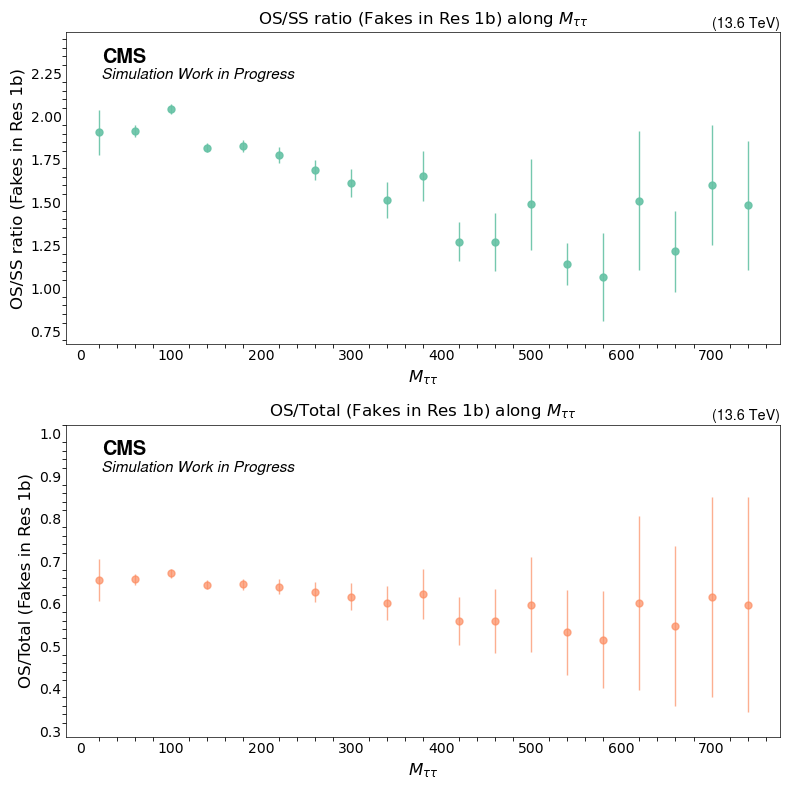

In [12]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiTau_mass', r'$M_{\tau \tau}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiTauM_1b.png', 20, (0, 800), 'weight')

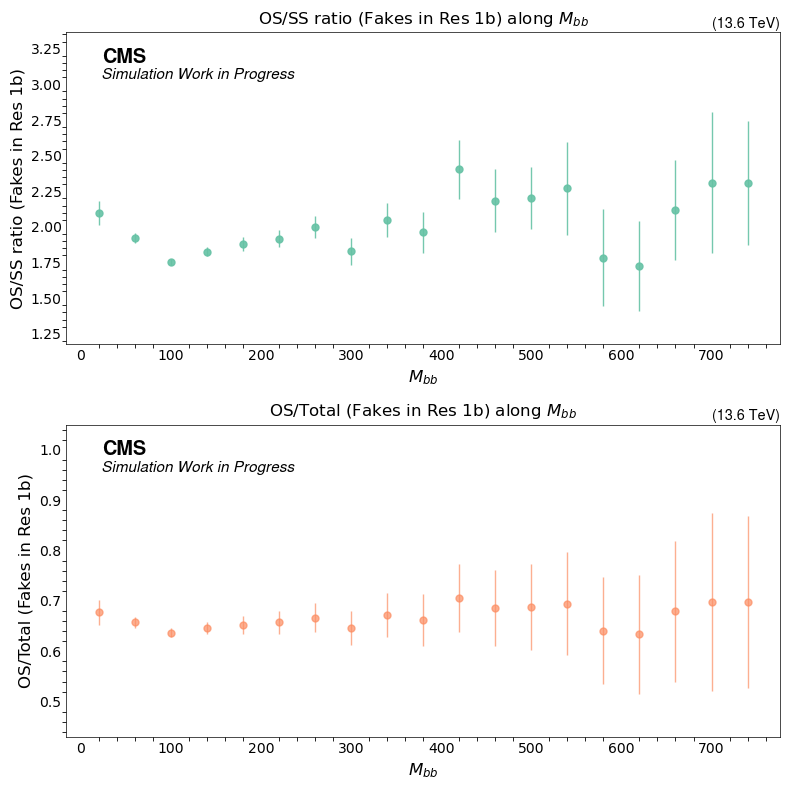

In [13]:
PlotUtil.corr_discrete(df_1b, 'OS', 'DiJet_mass', r'$M_{bb}$', 'OS/SS ratio (Fakes in Res 1b)', 'OS/Total (Fakes in Res 1b)', f'{plot_dir}/OSRatio_DiJetM_1b.png', 20, (0, 800), 'weight')

In [14]:
# further split the data into training and testing based on mass
def split_mass(df_ori):
    df = df_ori.copy()[(df_ori['DiJet_mass'] > 90)]
    condition = df['DiJet_mass'] > 160
    train = df[condition]
    test = df[~condition]
    return train, test

train_df, val_df = split_mass(df_1b)

In [15]:
cond = train_df['OS'] == False
ss_df = train_df[cond]
os_df = train_df[~cond]

In [16]:
val_cond = val_df['OS'] == False
val_ss_df = val_df[val_cond]
val_os_df = val_df[~val_cond]
# sig_cond = val_os_df['DiTau_mass'] > 60
# val_os_df = val_os_df[sig_cond]
# val_os_df = signal_id_level(val_os_df)

In [17]:
from src.utils.mathutil import ABCDUtil
ABCD_Helper = ABCDUtil(val_os_df, os_df, val_ss_df, ss_df, 'weight')
ABCD_Helper.get_all_stats()

          Events (Raw)  Events (Weighted)
Region                                   
Region A         70379               6798
Region B         51762               5169
Region C         40744               3761
Region D         28979               2660
The closure stats for Events (Raw): 
                                  Value
Metric                                 
Predicted events in A    72776 ± 644.26
Prediction/Actual ratio           1.034
Pull significance                -6.335
Deviation                        -3.721
Percentage difference              3.4%
The closure stats for Events (Weighted): 
                                 Value
Metric                                
Predicted events in A    7307 ± 211.16
Prediction/Actual ratio          1.075
Pull significance               -4.282
Deviation                       -2.409
Percentage difference             7.5%


In [20]:
results_dir = "/Users/yuntongzhou/Desktop/Dihiggszztt/output"
drop_kwds = ['Gen', 'weight_values', 'Weight_values', 'OS', 'group', 'gen', 'dataset', 'label', 'btag', 'RecoH_dR', 'id', 'year', 'Tau_charge', 'X_num']
rwgter = SingleXGBReweighter(ss_df, os_df, 'weight', results_dir)
rwgter.prep_data(drop_kwds)

Dropped  190  events with negative weights out of  28979  events.
Dropped  333  events with negative weights out of  51762  events.
X columns: 
Index(['LDTau_pt', 'LDTau_eta', 'LDTau_phi', 'LDTau_mass', 'LDTau_dxy',
       'LDTau_dz', 'SDTau_pt', 'SDTau_eta', 'SDTau_phi', 'SDTau_mass',
       'SDTau_dxy', 'SDTau_dz', 'LDBjet_pt', 'LDBjet_eta', 'LDBjet_phi',
       'LDBjet_mass', 'SDBjet_pt', 'SDBjet_eta', 'SDBjet_phi', 'SDBjet_mass',
       'DiTau_pt', 'DiTau_eta', 'DiTau_phi', 'DiTau_mass', 'DiJet_pt',
       'DiJet_eta', 'DiJet_phi', 'DiJet_mass', 'Tau_dR', 'Bjet_dR', 'HT',
       'LDTau_px', 'LDTau_py', 'LDTau_pz', 'SDTau_px', 'SDTau_py', 'SDTau_pz',
       'LDBjet_px', 'LDBjet_py', 'LDBjet_pz', 'SDBjet_px', 'SDBjet_py',
       'SDBjet_pz', 'DiTau_px', 'DiTau_py', 'DiTau_pz', 'DiJet_px', 'DiJet_py',
       'DiJet_pz'],
      dtype='object')


[0]	train-logloss:0.63901+0.00234	train-auc:0.68376+0.00884	train-rmse:0.47282+0.00118	test-logloss:0.64368+0.00980	test-auc:0.52388+0.01783	test-rmse:0.47503+0.00502
[20]	train-logloss:0.56005+0.00261	train-auc:0.88324+0.00333	train-rmse:0.43380+0.00124	test-logloss:0.63850+0.01001	test-auc:0.56206+0.01258	test-rmse:0.47259+0.00510
[40]	train-logloss:0.50815+0.00243	train-auc:0.92240+0.00317	train-rmse:0.40760+0.00119	test-logloss:0.63841+0.01004	test-auc:0.56538+0.01366	test-rmse:0.47258+0.00508
[48]	train-logloss:0.49143+0.00207	train-auc:0.93353+0.00253	train-rmse:0.39908+0.00102	test-logloss:0.63855+0.01029	test-auc:0.56604+0.01618	test-rmse:0.47265+0.00516
Optimal number of boosting rounds: 29


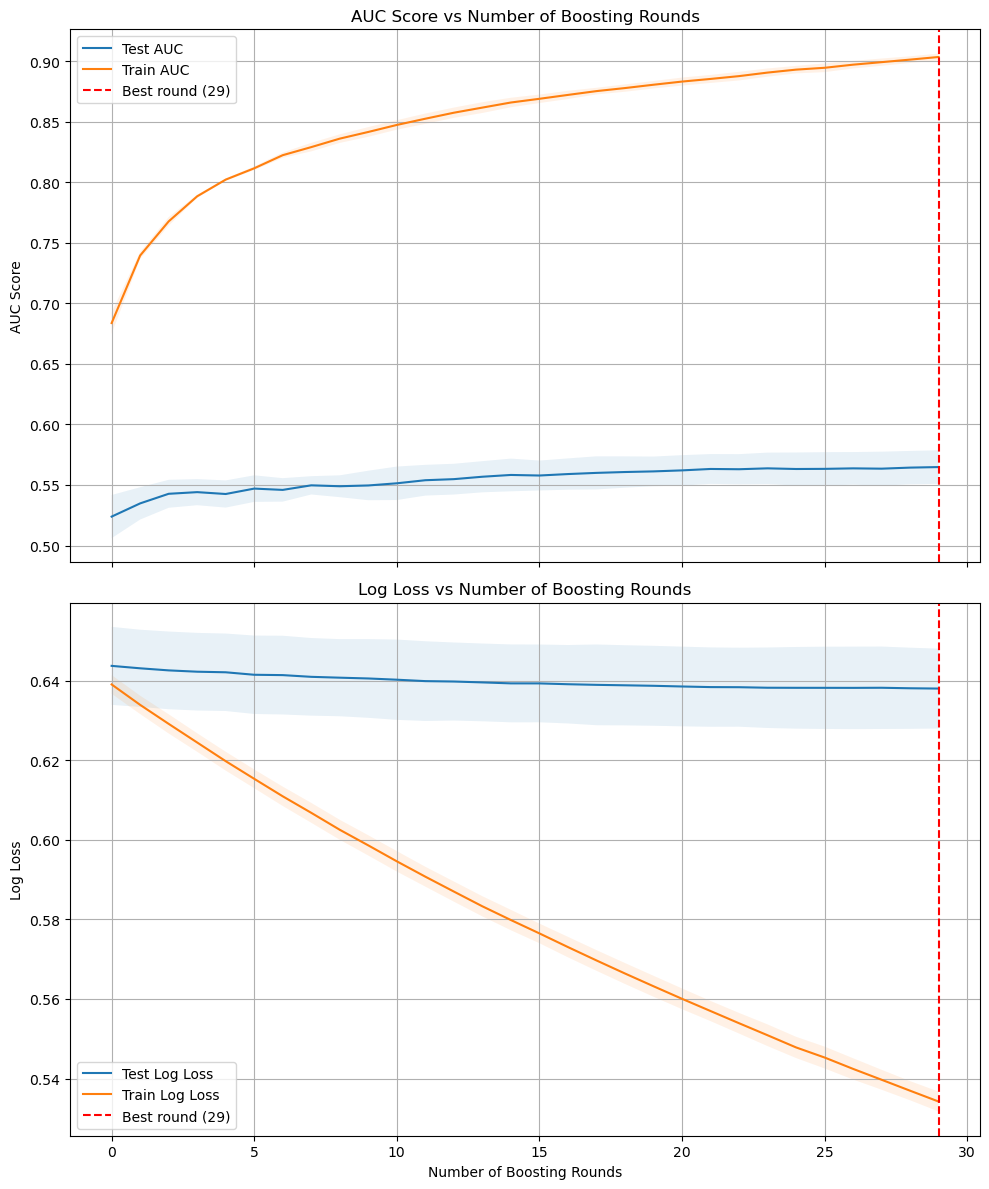

In [21]:
rwgter.boostingSearch(20, 50, booster='dart')

In [22]:
rwgter.train(save=True, savename='trained_models/depth_20_dart_fake.json')

[0]	train-logloss:0.63823	test-logloss:0.63487
[28]	train-logloss:0.53666	test-logloss:0.63166


ROC AUC Score: 0.555
Accuracy:  0.6448932103382365


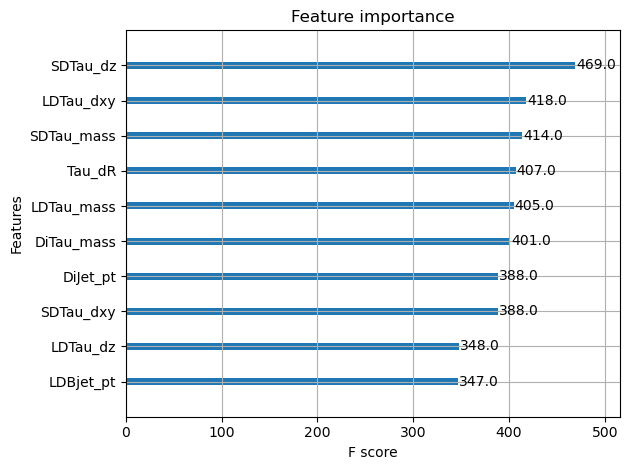

In [23]:
rwgter.evaluate()

In [41]:
# Change Naming Here
prefix = 'rwgt'
pjoin = os.path.join
savedir = pjoin('training', 'TTbar_only_fake_1b')

In [42]:
norm_SS = ss_df['weight'].sum()
norm_OS = os_df['weight'].sum()
rwgt_SS = rwgter.reweight(ss_df, norm_OS, drop_kwds, False)

Dropped  190  events with negative weights out of  28979  events.


In [43]:
norm_SS_val = val_ss_df['weight'].sum()
norm_OS_val = val_os_df['weight'].sum()
rwgt_SS_val = rwgter.reweight(val_ss_df, norm_OS_val, drop_kwds, False)

Dropped  171  events with negative weights out of  40744  events.


In [44]:
from src.plotting.visutil import CSVPlotter

In [45]:
plot_dir_name = 'TTbar_1b'
out_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/plots/{plot_dir_name}'
data_dir = f'/Users/yuntongzhou/Desktop/Dihiggszztt/output/{savedir}'

modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,400]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [160,600]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
from config.plotsetting import tau_pt, dR

In [ ]:
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 160', save_suffix='rwgt')
CSVPlotter.plot_shape([os_df, ss_df, rwgt_SS], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ > 160', save_suffix='rwgt')

In [ ]:
modified_H_mass = {
    "DiTau_mass": {
        "hist": {'bins': 30, 'range': [0,300]},
        "plot": {'xlabel': r'Visible Mass (2$\tau$) (GeV)'}},
    "DiJet_mass": {
        "hist": {'bins': 40, 'range': [0,160]},
        "plot": {'xlabel': r'Invariant Mass (2b) (GeV)'}},
}
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], modified_H_mass, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')
CSVPlotter.plot_shape([val_os_df, val_ss_df, rwgt_SS_val], ['OS', 'original SS', 'Reweighted SS'], dR, 'Pred/Actual', out_dir, title=r'$M_{bb}$ < 150', save_suffix='rwgt_sig')